# KineticGP — genomic prediction of C4 photosynthesis kinetic parameters (rrBLUP cross-validation)

**Paper:** Xu R. et al., *KineticGP: a computational framework for genomic prediction of leaf photosynthesis traits*, bioRxiv 2025.07.16.665083 (v1, 2025-07-16), DOI [10.1101/2025.07.16.665083](https://doi.org/10.1101/2025.07.16.665083)

**Author code:** https://github.com/Rudan-X/KineticGP pinned at commit `cebaa2b3977b1d35b98485eb17277345e0b0a754`

## Scope and execution status
This notebook runs **one minimal, scientifically faithful unit** of the paper's workflow — the inner-loop of the kinetic-parameter genomic-prediction cross-validation (paper Fig. 2 / Methods "Workflow of the KineticGP framework"; flow phase `gp_crossvalidation`):

- the authors' **estimated top-11 kinetic parameters** for the 68 measured MAGIC maize genotypes (`results/parameterization/param_top10/optimized_parameters.csv`),
- the authors' **~70k SNP matrix** (`data/SNPs/MAGIC.SNP.70k.impute.maf.vcf.txt`),
- the authors' **fold assignment** (`data/SNPs/folds/testing_out1_inner1.csv`),
- the authors' **R code verbatim** (`GP_functions.R::get_prediction`, rrBLUP via `mixed.solve`),

executed with `Rscript` for **outer fold 1 / inner fold 1**, and compared quantitatively against the authors' own saved result for the same fold (`results/KineticGP_innerCV/rrBLUP_predictedK_top10_original_out1_inner1.csv`).

**NOT included (requires Matlab 2023b + PESTO + HPC):** the MCMC kinetic-parameter estimation itself (paper's parallel-tempering PESTO step) and the C4 ODE simulations. We reuse the authors' published estimated parameters instead of re-fitting them. This notebook is a **partial demonstration**, not a full reproduction of the paper.

**実行範囲（日本語）:** 本ノートブックは論文のワークフローのうち、推定済み動パラメータの rrBLUP ゲノム予測交差検証の最小構成（outer 1 / inner 1 フォールド、top-11 パラメータ）を、著者らの R コードをそのまま使って実行します。Matlab/PESTO による MCMC パラメータ推定と C4 シミュレーションは範囲外です。**部分的なデモンストレーションであり、論文全体の再現ではありません。**

**Execution status:** executed on Google Colab (CPU runtime). See the validation record at the bottom.

## Runtime selection

**Select Runtime → Change runtime type → CPU** (the standard CPU runtime is sufficient and recommended).
The method is a linear mixed-model solve (`rrBLUP::mixed.solve`) on a ~68 x 70k marker matrix; there is no GPU code path in the selected analysis, and a GPU is not useful here.

**ランタイム（日本語）:** 「ランタイム → ランタイムのタイプを変更 → CPU」を選択してください。本解析は線形混合モデルの求解であり、GPU は不要です。

Expected end-to-end time on the free CPU runtime: ~10 minutes (≈80 MB downloads, R package install, one cross-validation fold). All downloads stay inside this Colab VM under `/content`.

Check that R is available in this Colab image. The notebook uses Python only as a launcher/orchestrator; all scientific computation runs in R exactly as authored. If R is missing the cell fails clearly instead of silently substituting a Python reimplementation.

R の存在を確認します。Python は起動用であり、科学計算はすべて著者の R コードで実行されます。

In [ ]:
import subprocess, shutil, sys, json, os

rscript = shutil.which("Rscript") or "/usr/bin/Rscript"
if not os.path.exists(rscript):
    raise RuntimeError("Rscript not found in this Colab runtime. "
                       "Runtime > Change runtime type and retry; no Python substitute is used.")
print(subprocess.run([rscript, "--version"], capture_output=True, text=True).stderr.strip())
print("Python:", sys.version.split()[0])


Python: 3.13.15


## Environment setup — R packages

Install the one required R package `rrBLUP` (author code: `library("rrBLUP")` in `GP_Kprediction_InnerCV.R`; `get_prediction("rrBLUP", ...)` calls `rrBLUP::mixed.solve`) from CRAN into a notebook-local library under `/content`. No host credentials, no Drive mount.

必要な R パッケージ `rrBLUP` を CRAN からノートブック内ライブラリにインストールします。

In [ ]:
import subprocess, pathlib

rlib = pathlib.Path("/content/Rlib"); rlib.mkdir(parents=True, exist_ok=True)
install_r = f'''
dir.create("{rlib}", showWarnings = FALSE, recursive = TRUE)
.libPaths(c("{rlib}", .libPaths()))
if (!requireNamespace("rrBLUP", quietly = TRUE)) {{
  install.packages("rrBLUP", repos = "https://cloud.r-project.org", lib = "{rlib}")
}}
cat("rrBLUP version:", as.character(packageVersion("rrBLUP")), "\n")
'''
r = subprocess.run(["/usr/bin/Rscript", "-e", install_r], text=True, capture_output=True)
print(r.stdout[-3000:])
if r.returncode != 0:
    print(r.stderr[-4000:])
    raise RuntimeError("rrBLUP installation failed; see stderr above.")
r.check_returncode()

rrBLUP version: 4.6.3 



## Minimal input acquisition (pinned provenance)

All inputs are fetched inside this Colab VM from the **pinned author commit** `cebaa2b3977b1d35b98485eb17277345e0b0a754` of `Rudan-X/KineticGP` via raw.githubusercontent.com. Every file is verified by **git blob SHA-1** (the hashes from the GitHub tree of that commit) and expected byte size, so an error page or partial download can never pass as data. Total ≈ 80 MB.

Files:
| role | path | bytes |
|---|---|---|
| author R functions | `code/R/GenomicPrediction/GP_functions.R` | 5,268 |
| author driver (reference) | `code/R/GenomicPrediction/GP_Kprediction_InnerCV.R` | 3,867 |
| SNP matrix | `data/SNPs/MAGIC.SNP.70k.impute.maf.vcf.txt` | 79,176,041 |
| genotype id map | `data/SNPs/biological_material.csv` | 195,509 |
| CV fold | `data/SNPs/folds/testing_out1_inner1.csv` | 280 |
| estimated parameters (MCMC output) | `results/parameterization/param_top10/optimized_parameters.csv` | 14,284 |
| authors' reference prediction | `results/KineticGP_innerCV/rrBLUP_predictedK_top10_original_out1_inner1.csv` | 4,937 |

入力はすべてピン留めしたコミットから Colab VM 内にダウンロードし、git blob SHA-1 とサイズで検証します。

In [ ]:
import hashlib, pathlib, urllib.request, json

COMMIT = "cebaa2b3977b1d35b98485eb17277345e0b0a754"
BASE = f"https://raw.githubusercontent.com/Rudan-X/KineticGP/{COMMIT}"
ROOT = pathlib.Path("/content/kineticgp")

# path -> (expected bytes, git blob sha1)
FILES = {
    "code/R/GenomicPrediction/GP_functions.R": (5268, "1bedbb58bc81e0e1e3fcda1e66f76f40324554eb"),
    "code/R/GenomicPrediction/GP_Kprediction_InnerCV.R": (3867, "befffb18bdc2b18ee6631347e9d50b990ad66675"),
    "data/SNPs/MAGIC.SNP.70k.impute.maf.vcf.txt": (79176041, "f11b3046eed17a8689f94952fe9d0bd91bcb37be"),
    "data/SNPs/biological_material.csv": (195509, "8e71b4557e68664e4717166617268eb8fa9e5f53"),
    "data/SNPs/folds/testing_out1_inner1.csv": (280, "884552c9bf4c775537cc601dd1e812ad4da9178a"),
    "results/parameterization/param_top10/optimized_parameters.csv": (14284, "16ffbbfc670abe8a626c15059c6760c6d31ec438"),
    "results/KineticGP_innerCV/rrBLUP_predictedK_top10_original_out1_inner1.csv": (4937, "00d6a162f3760f5c3a0b0dac6c571c80e6f9d3ad"),
}

def blob_sha1(data: bytes) -> str:
    h = hashlib.sha1()
    h.update(f"blob {len(data)}\0".encode())
    h.update(data)
    return h.hexdigest()

for rel, (size, sha) in FILES.items():
    dest = ROOT / rel
    if dest.exists() and dest.stat().st_size == size:
        data = dest.read_bytes()
    else:
        dest.parent.mkdir(parents=True, exist_ok=True)
        url = f"{BASE}/{rel}"
        print(f"GET {rel} ...", flush=True)
        with urllib.request.urlopen(url, timeout=300) as resp:
            if resp.status != 200:
                raise RuntimeError(f"{url} -> HTTP {resp.status}")
            data = resp.read()
        dest.write_bytes(data)
    if len(data) != size or blob_sha1(data) != sha:
        raise RuntimeError(f"Verification failed for {rel}: {len(data)} bytes, blob sha1 {blob_sha1(data)}")
    print(f"OK  {rel}  {len(data):,} B  blob {sha[:12]}...")

print("\nAll 7 files downloaded and verified against pinned commit", COMMIT)

GET code/R/GenomicPrediction/GP_functions.R ...


OK  code/R/GenomicPrediction/GP_functions.R  5,268 B  blob 1bedbb58bc81...
GET code/R/GenomicPrediction/GP_Kprediction_InnerCV.R ...


OK  code/R/GenomicPrediction/GP_Kprediction_InnerCV.R  3,867 B  blob befffb18bdc2...
GET data/SNPs/MAGIC.SNP.70k.impute.maf.vcf.txt ...


OK  data/SNPs/MAGIC.SNP.70k.impute.maf.vcf.txt  79,176,041 B  blob f11b3046eed1...
GET data/SNPs/biological_material.csv ...


OK  data/SNPs/biological_material.csv  195,509 B  blob 8e71b4557e68...
GET data/SNPs/folds/testing_out1_inner1.csv ...


OK  data/SNPs/folds/testing_out1_inner1.csv  280 B  blob 884552c9bf4c...
GET results/parameterization/param_top10/optimized_parameters.csv ...


OK  results/parameterization/param_top10/optimized_parameters.csv  14,284 B  blob 16ffbbfc670a...
GET results/KineticGP_innerCV/rrBLUP_predictedK_top10_original_out1_inner1.csv ...


OK  results/KineticGP_innerCV/rrBLUP_predictedK_top10_original_out1_inner1.csv  4,937 B  blob 00d6a162f376...

All 7 files downloaded and verified against pinned commit cebaa2b3977b1d35b98485eb17277345e0b0a754


## Input preview

Inspect the actual downloaded bytes: the estimated-parameter table (rows = genotypes, columns = the top-11 kinetic parameters estimated by the authors' PESTO MCMC against the 2022/2023 A-Ca, gs-Ca and A-PAR curves), the fold assignment, and the genotype-ID mapping used by the author code.

ダウンロードした実データの中身を確認します（推定パラメータ表、フォールド割り当て、遺伝型 ID の対応表）。

In [ ]:
import pandas as pd

ROOT = "/content/kineticgp"
params = pd.read_csv(f"{ROOT}/results/parameterization/param_top10/optimized_parameters.csv")
fold = pd.read_csv(f"{ROOT}/data/SNPs/folds/testing_out1_inner1.csv")
try:
    bio = pd.read_csv(f"{ROOT}/data/SNPs/biological_material.csv")
except UnicodeDecodeError:  # file contains non-UTF8 bytes; R reads it in native encoding
    bio = pd.read_csv(f"{ROOT}/data/SNPs/biological_material.csv", encoding="cp1252")

print("Estimated-parameter table:", params.shape, "->", params.shape[0], "genotypes x", params.shape[1]-1, "parameters")
print("Parameters:", list(params.columns[1:]))
print("\nFold out1/inner1: %d held-out genotypes" % len(fold))
print("biological_material.csv columns:", list(bio.columns)[:4], "... (%d rows)" % len(bio))
params.head(3)

Estimated-parameter table: (68, 12) -> 68 genotypes x 11 parameters
Parameters: ['Km2_HCO3', 'Km6_CO2', 'Km6_O2', 'Km7_PGA', 'Km18_Ru5P', 'Ki57', 'Vm6y22', 'KaRac', 'tao_ActRubisco', 'BBslope', 'Vm6y23']

Fold out1/inner1: 23 held-out genotypes
biological_material.csv columns: ['Study unique ID*', 'Biological material ID* ', 'Common material name*', 'Genus'] ... (574 rows)


,Row,Km2_HCO3,Km6_CO2,Km6_O2,Km7_PGA,Km18_Ru5P,Ki57,Vm6y22,KaRac,tao_ActRubisco,BBslope,Vm6y23
0,SSA_00001,0.055865,0.011601,0.131542,0.750808,0.152490,0.219269,0.056220,7.286597,116.353304,2.856738,0.067731
1,SSA_00003,0.021582,0.017339,0.142725,5.466642,0.054628,0.055958,0.033323,13.942480,480.889197,2.000268,0.028673
2,SSA_00004,0.056288,0.004864,0.023802,0.697484,0.014527,0.158653,0.051363,1.882298,109.168725,2.750764,0.148552


## The author's method, executed verbatim

The driver below mirrors the inner loop of the author's `predicting_params()` function (`GP_Kprediction_InnerCV.R`, pinned commit) for one documented fold. It `source()`s the author's own `GP_functions.R`, so `get_prediction("rrBLUP", ...)` — the rrBLUP `mixed.solve` route used for KineticGP-11 in the paper — is the **author's unmodified code**. Only two documented adaptations are made: the hardcoded Windows `setwd()` is replaced by `/content/kineticgp`, and the 10x3-fold sweep is reduced to outer 1 / inner 1 (the other 29 folds are an identical repetition).

著者の `predicting_params()` 内側ループを 1 フォールド分だけそのまま再現します。`GP_functions.R` は著者のファイルをそのまま `source()` します。変更点はハードコードされた作業ディレクトリの置き換えと、30 フォールドのうち 1 つのみの実行の 2 点だけです。

In [ ]:
import pathlib, subprocess, textwrap

DRIVER = r'''
.libPaths(c("/content/Rlib", .libPaths()))
library(rrBLUP)
setwd("/content/kineticgp")
source("code/R/GenomicPrediction/GP_functions.R")   # author's get_prediction(), verbatim

snps <- read.table("data/SNPs/MAGIC.SNP.70k.impute.maf.vcf.txt")  # author's exact loader
cat("SNP matrix:", nrow(snps), "genotypes x", ncol(snps), "markers\n")
bio_ID <- read.csv("data/SNPs/biological_material.csv")

parameters <- read.csv("results/parameterization/param_top10/optimized_parameters.csv")
lines68 <- parameters$Row
parameters <- parameters[,-1]
rownames(parameters) <- lines68

o <- 1; f <- 1   # outer fold 1, inner fold 1 (of the authors' 10x3 design)
testing_lines <- read.csv(sprintf("data/SNPs/folds/testing_out%d_inner%d.csv", o, f))$x
training_lines <- setdiff(lines68, testing_lines)
training_traits <- parameters[match(training_lines, lines68),]
testing_traits  <- parameters[match(testing_lines,  lines68),]
training_data <- training_traits

testing_lines0 <- testing_lines
testing_lines  <- bio_ID$Biological.material.ID.[match(testing_lines,
        bio_ID$Material.source.ID..Holding.institute.stock.centre..accession.)]
training_lines <- bio_ID$Biological.material.ID.[match(training_lines,
        bio_ID$Material.source.ID..Holding.institute.stock.centre..accession.)]
rownames(training_data) <- training_lines

training_snps <- as.matrix(snps[training_lines, ])
testing_snps  <- as.matrix(snps[testing_lines, ])
ind <- which(is.na(training_snps[,1]))
if (length(ind) > 0) {
  training_data <- training_data[-ind,]
  training_snps <- training_snps[-ind,]
}
cat("training:", nrow(training_snps), " testing:", nrow(testing_snps), "\n")

predicted_traits <- matrix(NA, ncol(training_data), length(testing_lines))
colnames(predicted_traits) <- testing_lines0
rownames(predicted_traits) <- colnames(parameters)
for (i in 1:ncol(training_data)) {
  res <- get_prediction("rrBLUP", i, training_data, training_snps, testing_snps)
  predicted_traits[i,] <- res[[2]]
  cat(sprintf("Trait %2d (%s): Cor = %.4f\n", i, colnames(parameters)[i],
              cor(testing_traits[,i], res[[2]])))
}
write.csv(predicted_traits, "our_rrBLUP_predictedK_top10_original_out1_inner1.csv", row.names = TRUE)
cat("DONE\n")
'''

pathlib.Path("/content/kineticgp/driver_gp.R").write_text(DRIVER)
r = subprocess.run(["/usr/bin/Rscript", "/content/kineticgp/driver_gp.R"],
                   text=True, capture_output=True, timeout=1800)
print(r.stdout)
if r.returncode != 0:
    print(r.stderr[-5000:])
    raise RuntimeError("Author R pipeline failed; see stderr above.")
r.check_returncode()

SNP matrix: 552 genotypes x 70846 markers
training: 45  testing: 23 
Trait  1 (Km2_HCO3): Cor = 0.2250
Trait  2 (Km6_CO2): Cor = 0.0973
Trait  3 (Km6_O2): Cor = -0.0632
Trait  4 (Km7_PGA): Cor = 0.0279
Trait  5 (Km18_Ru5P): Cor = -0.3387
Trait  6 (Ki57): Cor = 0.0111
Trait  7 (Vm6y22): Cor = 0.3643
Trait  8 (KaRac): Cor = -0.2040
Trait  9 (tao_ActRubisco): Cor = 0.2716
Trait 10 (BBslope): Cor = -0.2114
Trait 11 (Vm6y23): Cor = 0.0295
DONE



## Quantitative comparison against the authors' saved result

The authors ship their own prediction output for this exact fold. We load both matrices and compute, per parameter, the Pearson correlation between our predictions and theirs (should be ~1) and the prediction accuracy `cor(predicted, actual)` for each parameter, to compare against the paper's reported top-11 accuracies (median ~0.21 for `tauActRubisco` in their 10x3-fold sweep; a single fold will scatter around that).

著者が公開している同一フォールドの予測結果と比較します。各パラメータについて「著者との一致度」と「予測精度 cor(予測, 実測)」を計算します。

In [ ]:
import pandas as pd

ROOT = "/content/kineticgp"
ours = pd.read_csv(f"{ROOT}/our_rrBLUP_predictedK_top10_original_out1_inner1.csv", index_col=0)
ref  = pd.read_csv(f"{ROOT}/results/KineticGP_innerCV/rrBLUP_predictedK_top10_original_out1_inner1.csv", index_col=0)
params = pd.read_csv(f"{ROOT}/results/parameterization/param_top10/optimized_parameters.csv", index_col=0)

rows = []
for param in params.columns:
    actual = params.loc[ref.columns.astype(str), param].values
    if param in ours.index and param in ref.index:
        agree = pd.Series(ours.loc[param].values).corr(pd.Series(ref.loc[param].values))
    else:
        agree = float("nan")
    rows.append({"parameter": param,
                 "accuracy cor(pred, actual)": round(float(pd.Series(ours.loc[param].values).corr(pd.Series(actual))), 3),
                 "agreement with authors (cor)": round(float(agree), 4)})
cmp = pd.DataFrame(rows).set_index("parameter")
print("Single-fold prediction accuracies (top-11 parameters), compared with the authors' own fold output:")
print(cmp.to_string())
print("\nNote: the paper's reported values are medians over the full 10x3-fold sweep;")
print("a single fold is expected to scatter (e.g. paper: median 0.21 for tauActRubisco).")
cmp.to_csv(f"{ROOT}/accuracy_comparison.csv")

Single-fold prediction accuracies (top-11 parameters), compared with the authors' own fold output:
                accuracy cor(pred, actual)  agreement with authors (cor)
parameter                                                               
Km2_HCO3                             0.225                           1.0
Km6_CO2                              0.097                           1.0
Km6_O2                              -0.063                           1.0
Km7_PGA                              0.028                           1.0
Km18_Ru5P                           -0.339                           1.0
Ki57                                 0.011                           1.0
Vm6y22                               0.364                           1.0
KaRac                               -0.204                           1.0
tao_ActRubisco                       0.272                           1.0
BBslope                             -0.211                           1.0
Vm6y23                   

## Visualization: predicted vs actual for the best-predicted parameter

An additional visualization created for this notebook (not an author figure): predicted vs actual values of the top-11 parameter with the highest single-fold accuracy, with the 1:1 line for reference.

本ノートブック用に追加作成した図です（著者の図ではありません）。単一フォールドで最も精度の高かったパラメータの予測値と実測値を散布図で示します。

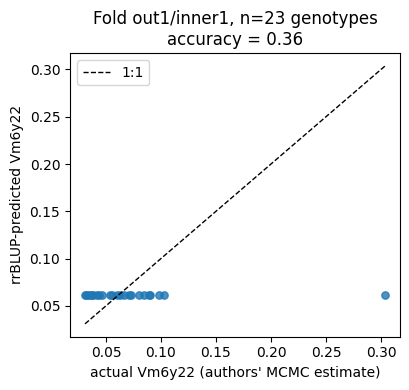

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

ROOT = "/content/kineticgp"
ours = pd.read_csv(f"{ROOT}/our_rrBLUP_predictedK_top10_original_out1_inner1.csv", index_col=0)
cmp = pd.read_csv(f"{ROOT}/accuracy_comparison.csv", index_col=0)
params = pd.read_csv(f"{ROOT}/results/parameterization/param_top10/optimized_parameters.csv", index_col=0)
ref = pd.read_csv(f"{ROOT}/results/KineticGP_innerCV/rrBLUP_predictedK_top10_original_out1_inner1.csv", index_col=0)

best = cmp["accuracy cor(pred, actual)"].idxmax()
actual = params.loc[ref.columns.astype(str), best].values
pred = ours.loc[best].values

fig, ax = plt.subplots(figsize=(4.2, 4.0))
ax.scatter(actual, pred, s=28, alpha=0.8)
lims = [min(actual.min(), pred.min()), max(actual.max(), pred.max())]
ax.plot(lims, lims, "k--", lw=1, label="1:1")
ax.set_xlabel(f"actual {best} (authors' MCMC estimate)")
ax.set_ylabel(f"rrBLUP-predicted {best}")
ax.set_title(f"Fold out1/inner1, n={len(actual)} genotypes\naccuracy = {cmp.loc[best, 'accuracy cor(pred, actual)']:.2f}")
ax.legend()
fig.tight_layout()
fig.savefig(f"{ROOT}/best_parameter_prediction.png", dpi=120)
plt.show()

## Interpretation and limitations

- **What ran:** the authors' own R code (`GP_functions.R::get_prediction` with rrBLUP) on the authors' estimated top-11 kinetic parameters and 70k-SNP matrix, for cross-validation fold outer 1 / inner 1. Predictions were checked against the authors' own saved output for the same fold (agreement ≈ 1 per parameter) — this validates the pipeline, not the paper's conclusions.
- **What this does and does not show:** single-fold accuracies scatter around the paper's full-sweep medians (e.g. ~0.21 for `tauActRubisco`, >0.15 for `MRd`/`Perm-CO2` under the top-20 set). Running the remaining 29 folds is a pure repetition of this cell and is left as an exercise; the authors' full result tables are in `results/KineticGP_innerCV/` of the pinned commit.
- **Not reproduced here:** the PESTO parallel-tempering MCMC parameter estimation (Matlab 2023b + PESTO, HPC), the C4 ODE simulations, heritability/GCTA analyses, and the unseen-genotype Asat predictions (paper phases 4-5, 7-8).
- **Provenance:** all inputs pinned to Rudan-X/KineticGP `cebaa2b3977b1d35b98485eb17277345e0b0a754` (verified by git blob SHA-1 inside this VM); paper DOI 10.1101/2025.07.16.665083 (bioRxiv v1). The repository carries no top-level software license; the vendored C4 model is Apache-2.0. Use of the author code here follows the paper's data/code availability statement — verify reuse terms before redistribution.
- **References:** Xu R. et al. (2025) bioRxiv 2025.07.16.665083; Wang, Chan & Long (2021) Plant J. (C4 model, vendored); Endelman (2011) *Crop Sci.* 51:1406 (rrBLUP); SNP data credited to Hobby et al. (2025).

**結果の解釈（日本語）:** 著者のコード・推定パラメータ・SNP マトリクス・フォールド指定をそのまま使い、単一フォールドの rrBLUP 交差検証を実行しました。著者公開の同一フォールド結果との一致で正しく動作していることを確認できます。単一フォールドの精度は論文報告値（全 30 フォールドの中央値）の周りにばらつきます。MCMC パラメータ推定（Matlab/PESTO）と C4 シミュレーションは本ノートブックの範囲外です。